# Exploratory Data Analysis: Singapore Museum Visitorship


## 0. Setup and Data Loading


In [326]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

sns.set_theme(style="whitegrid")

import sys
from pathlib import Path

In [327]:
# Repo root is one level up. Add repo root to sys.path so `config` and `src` are importable
sys.path.insert(0, str(Path.cwd().parent))

# Ensure changes to config and src are reflected in the notebook without restarting the kernel
import importlib
import config
import src.visualisation.eda
import src.features
importlib.reload(config)
importlib.reload(src.visualisation.eda)
importlib.reload(src.features)

from config import START_YEAR, START_MONTH, END_YEAR, END_MONTH, MUSEUM_CODES, COVID_START, COVID_END
from src.data.singstat_api import singstat_api
from src.features.data_prep import INTL_ARRIVALS_SERIES
from src.visualisation.eda import *
from src.visualisation.eda import get_shape, get_freq_dist

In [328]:
# Call the SingStat API to get the visitor and international arrivals
visitors = singstat_api("M891071", START_YEAR, START_MONTH, END_YEAR, END_MONTH)
intl_arrivals = singstat_api("M550001", START_YEAR, START_MONTH, END_YEAR, END_MONTH)

In [329]:
print("visitors shape:", get_shape(visitors))
print("intl_arrivals shape:", get_shape(intl_arrivals))

visitors shape: (1,898 rows, 3 cols)
intl_arrivals shape: (9,114 rows, 3 cols)


In [330]:
visitors.head()

,Data Series,Reporting Period,Value
0,Asian Civilisations Museum,2014 Jan,36.5
1,Asian Civilisations Museum,2014 Feb,37.7
2,Asian Civilisations Museum,2014 Mar,49.4
3,Asian Civilisations Museum,2014 Apr,46.5
4,Asian Civilisations Museum,2014 May,38.6


In [331]:
intl_arrivals.head()

,Data Series,Reporting Period,Value
0,Total International Visitor Arrivals By Place ...,2014 Jan,1345842
1,Total International Visitor Arrivals By Place ...,2014 Feb,1238239
2,Total International Visitor Arrivals By Place ...,2014 Mar,1297551
3,Total International Visitor Arrivals By Place ...,2014 Apr,1245307
4,Total International Visitor Arrivals By Place ...,2014 May,1208532


In [332]:
# Tidy the raw API output into a monthly, numeric, long-format frame for EDA.
def tidy_df(df):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["Reporting Period"], format="%Y %b")
    df["value"] = pd.to_numeric(df["Value"], errors="coerce").fillna(
        0
    )  # missing (e.g. "na", "-") -> 0
    return df.sort_values(["Data Series", "timestamp"]).reset_index(drop=True)


# Filter for selected museums, tagged with their short codes.
visitors_df = tidy_df(visitors)
visitors_df = visitors_df[visitors_df["Data Series"].isin(MUSEUM_CODES)].copy()
visitors_df["code"] = visitors_df["Data Series"].map(MUSEUM_CODES)

# Total international arrivals only
intl_arrivals_df = tidy_df(intl_arrivals)
intl_arrivals_df = intl_arrivals_df[
    intl_arrivals_df["Data Series"] == INTL_ARRIVALS_SERIES
].copy()

In [333]:
visitors_df

,Data Series,Reporting Period,Value,timestamp,value,code
0,Asian Civilisations Museum,2014 Jan,36.5,2014-01-01,36.5,ACM
1,Asian Civilisations Museum,2014 Feb,37.7,2014-02-01,37.7,ACM
2,Asian Civilisations Museum,2014 Mar,49.4,2014-03-01,49.4,ACM
3,Asian Civilisations Museum,2014 Apr,46.5,2014-04-01,46.5,ACM
4,Asian Civilisations Museum,2014 May,38.6,2014-05-01,38.6,ACM
...,...,...,...,...,...,...
1114,Peranakan Museum,2025 Nov,10.7,2025-11-01,10.7,TPM
1115,Peranakan Museum,2025 Dec,9.9,2025-12-01,9.9,TPM
1116,Peranakan Museum,2026 Jan,11.5,2026-01-01,11.5,TPM
1117,Peranakan Museum,2026 Feb,10.6,2026-02-01,10.6,TPM


In [334]:
intl_arrivals_df.head()

,Data Series,Reporting Period,Value,timestamp,value
8232,Total International Visitor Arrivals By Place ...,2014 Jan,1345842,2014-01-01,1345842
8233,Total International Visitor Arrivals By Place ...,2014 Feb,1238239,2014-02-01,1238239
8234,Total International Visitor Arrivals By Place ...,2014 Mar,1297551,2014-03-01,1297551
8235,Total International Visitor Arrivals By Place ...,2014 Apr,1245307,2014-04-01,1245307
8236,Total International Visitor Arrivals By Place ...,2014 May,1208532,2014-05-01,1208532


## 1. Data Quality and Integrity


In [335]:
# Per-museum coverage & completeness: date span, months present, and counts of
# truly-missing months, NaNs, and zeros (closures show up as zeros/missing).
full_idx = pd.date_range(
    visitors_df["timestamp"].min(), visitors_df["timestamp"].max(), freq="MS"
)

rows = []
for code, g in visitors_df.groupby("code"):
    rows.append(
        {
            "code": code,
            "start": g["timestamp"].min().strftime("%Y-%m"),
            "end": g["timestamp"].max().strftime("%Y-%m"),
            "n_months": len(g),
            "missing_months": len(
                full_idx.difference(pd.DatetimeIndex(g["timestamp"]))
            ),
            "n_nan": int(g["value"].isna().sum()),
            "n_zero": int((g["value"] == 0).sum()),
        }
    )

coverage = pd.DataFrame(rows).set_index("code")
print(
    f"Full monthly index spans {len(full_idx)} months: "
    f"{full_idx.min():%Y-%m} to {full_idx.max():%Y-%m}"
)
coverage

Full monthly index spans 147 months: 2014-01 to 2026-03


,start,end,n_months,missing_months,n_nan,n_zero
code,,,,,,
ACM,2014-01,2026-03,147,0,0,1
IHC,2015-05,2026-03,131,16,0,2
MHC,2014-01,2025-11,143,4,0,39
NMS,2014-01,2026-03,147,0,0,1
TPM,2014-01,2026-03,147,0,0,46


Heatmap of open periods with museum visitorship for all museums

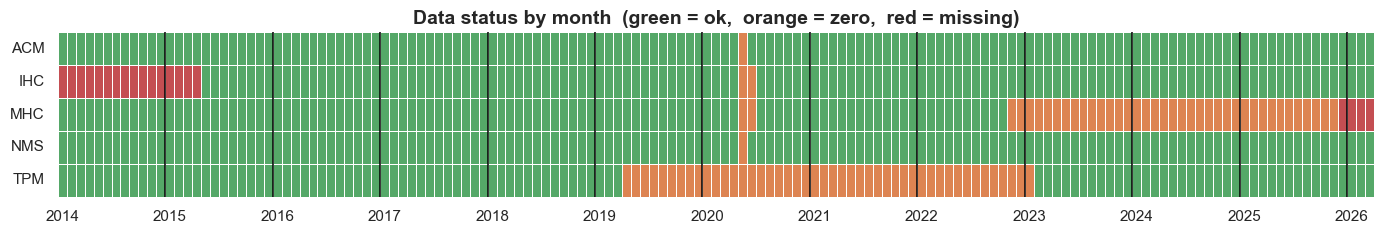

In [336]:
from matplotlib.colors import ListedColormap

# Pivot to a museum x month grid of values
pivot = visitors_df.pivot_table(
    index="code",
    columns=visitors_df["timestamp"].dt.strftime("%Y-%m"),
    values="value",
)

# Classify each cell: 0 = ok, 1 = zero, 2 = missing
status = pd.DataFrame(0, index=pivot.index, columns=pivot.columns)
status[pivot == 0] = 1
status[pivot.isna()] = 2

# Heatmap with white borders around every monthly cell
fig, ax = plt.subplots(figsize=(14, 2.5))
sns.heatmap(
    status,
    ax=ax,
    cbar=False,
    vmin=0,
    vmax=2,
    cmap=ListedColormap(["#55a868", "#dd8452", "#c44e52"]),  # green / orange / red
    linewidths=0.5,
    linecolor="white",
)

# Bold title
title = ax.set_title(
    "Data status by month  (green = ok,  orange = zero,  red = missing)",
    fontweight="bold",
)
title.set_fontsize(title.get_fontsize() + 2)

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# X-axis: tick + label only January of each year (labelled with the year)
jan = [(i, col[:4]) for i, col in enumerate(status.columns) if col.endswith("-01")]
ax.set_xticks([i + 0.5 for i, _ in jan])
ax.set_xticklabels([year for _, year in jan], rotation=0)

# Thick vertical lines at each year boundary (each January)
for i, _ in jan:
    if i > 0:
        ax.axvline(i, color="black", linewidth=1.1)

# Y-axis: keep museum labels horizontal
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 2. Univariate Analysis


### Target: `value` (Monthly Visitorship by Museum)


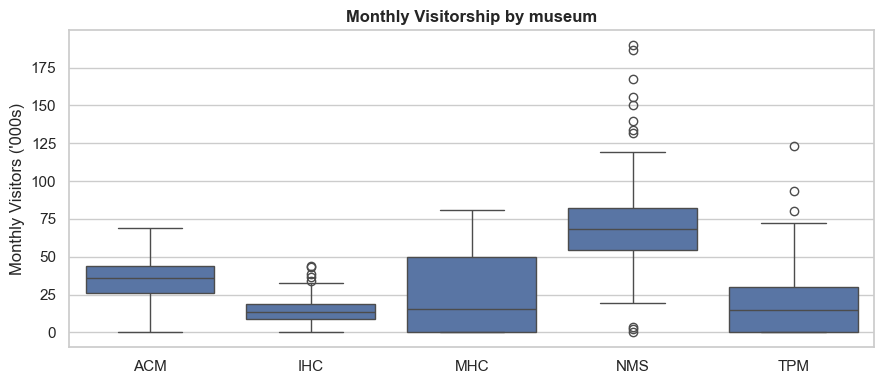

In [337]:
# Spread & outliers of monthly visitorship by museum.
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=visitors_df, x="code", y="value", ax=ax)
ax.set_title("Monthly Visitorship by museum", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Monthly Visitors ('000s)")
plt.tight_layout()
plt.show()

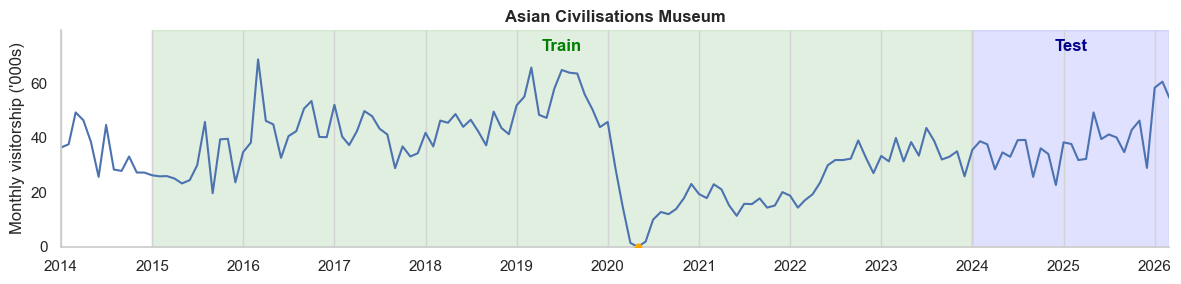

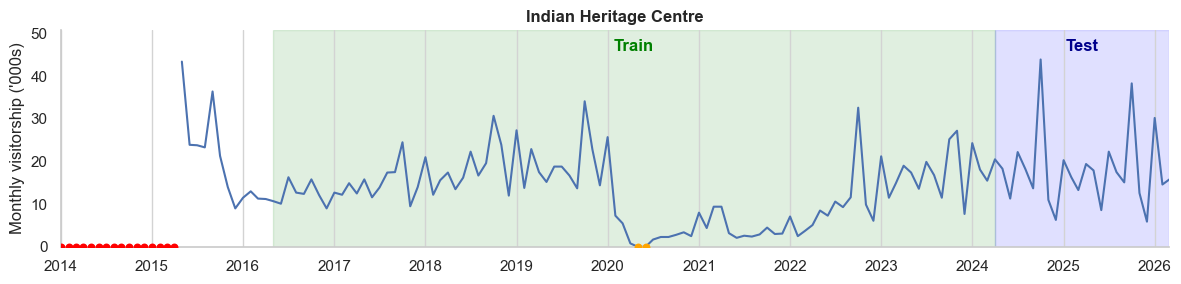

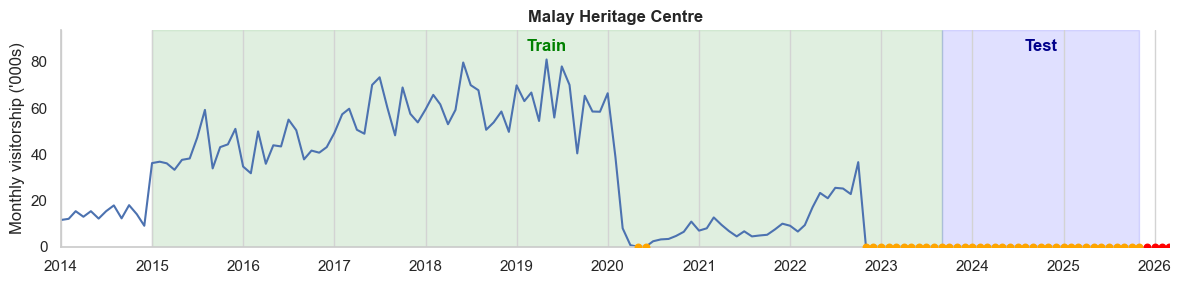

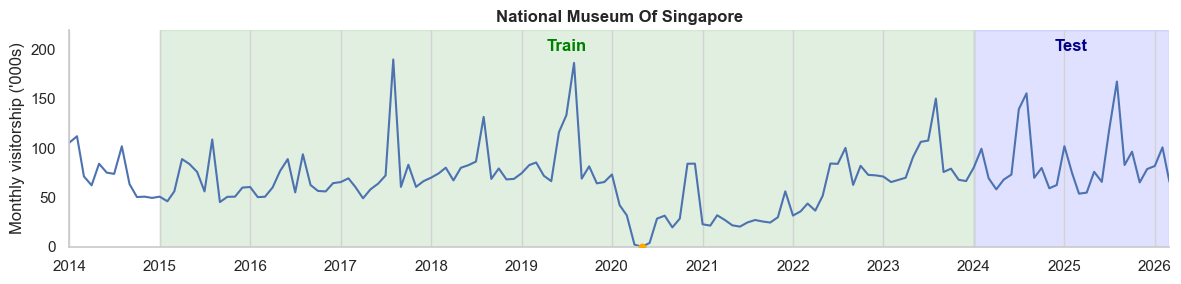

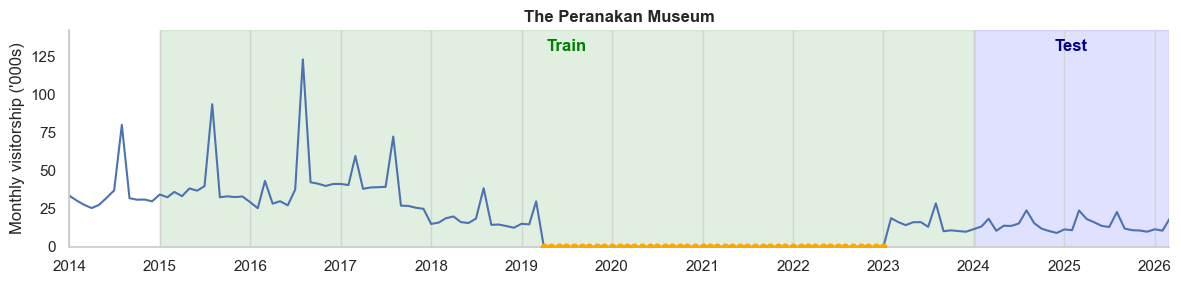

In [338]:
# One monthly-visitorship time series per museum (5 separate plots, shared x range).
from src.features.data_prep import prepare_eval_data

xmin, xmax = visitors_df["timestamp"].min(), visitors_df["timestamp"].max()
for museum_name, group in visitors_df.groupby("Data Series"):
    # Train/test boundaries from the pipeline's own 80/20 split (see prepare_eval_data)
    train_data, test_data, _ = prepare_eval_data(
        visitors[visitors["Data Series"] == museum_name], intl_arrivals
    )
    train_test = (
        train_data["timestamp"].min(),
        test_data["timestamp"].min(),
        test_data["timestamp"].max(),
    )

    # Adjust name for TPM from Singstat's given name to NHB's standard name
    if museum_name == "Peranakan Museum":
        museum_name = "The Peranakan Museum"
    
    plot_monthly_visitorship(
        group, title=museum_name, xmin=xmin, xmax=xmax, train_test=train_test
    )

### `intl_arrivals` (Jan 2014 - Mar 2026)


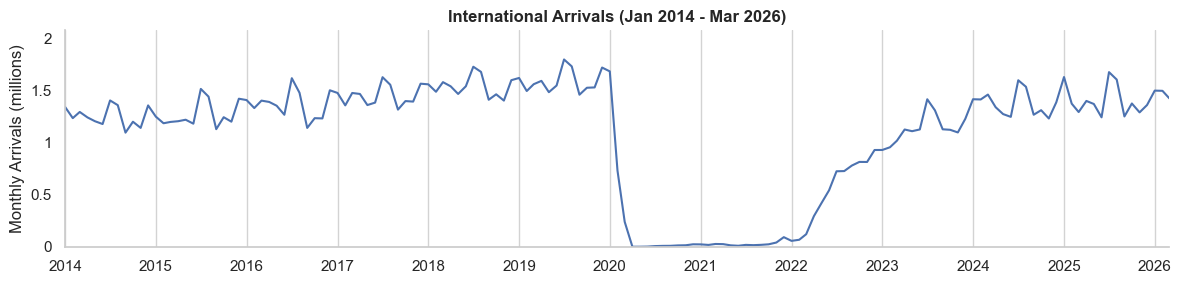

In [339]:
# Monthly international visitor arrivals (the exogenous feature, shared x range).
plot_monthly_visitorship(
    intl_arrivals_df,
    title=f"International Arrivals ({START_MONTH} {START_YEAR} - {END_MONTH} {END_YEAR})",
    xmin=xmin,
    xmax=xmax,
    ylabel="Monthly Arrivals (millions)",
    highlight_missing=True,
    y_millions=True,
)

### `is_covid`

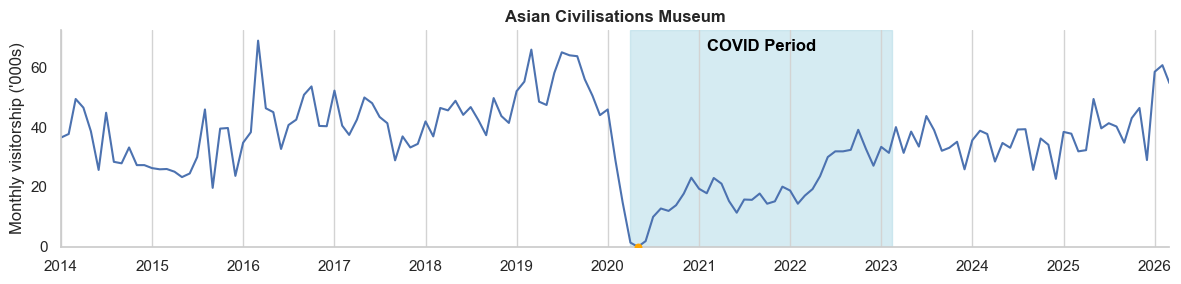

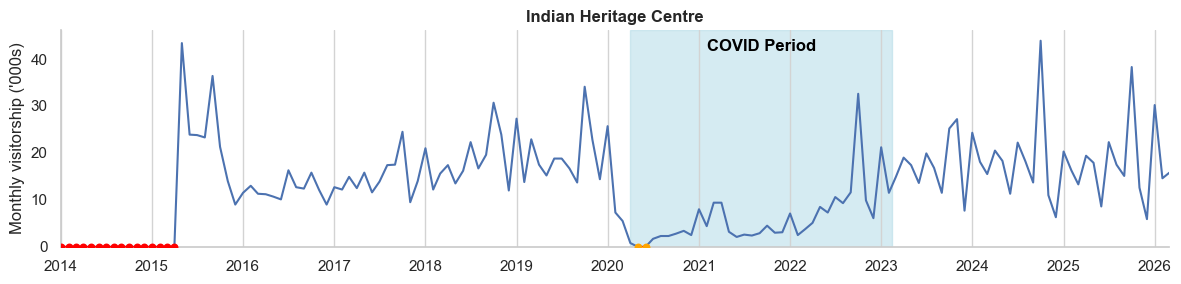

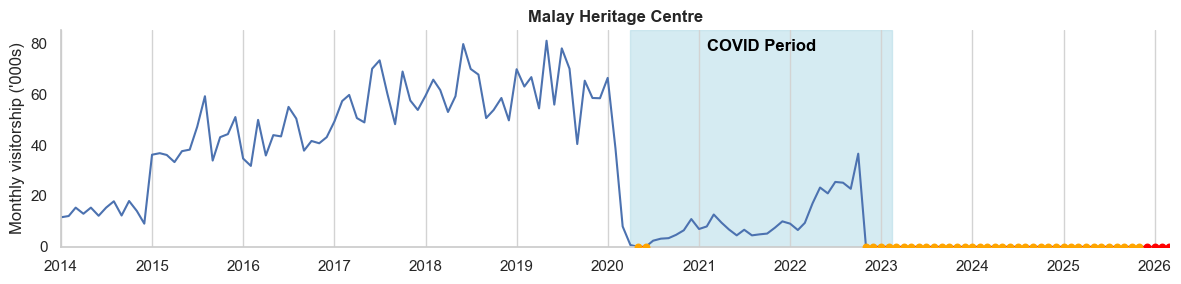

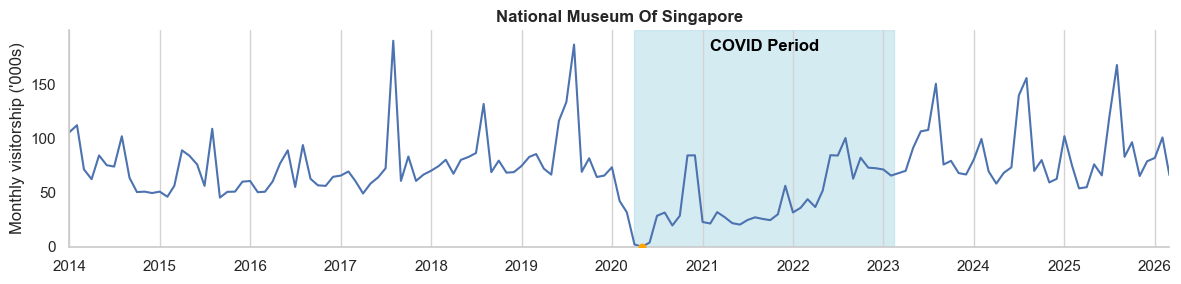

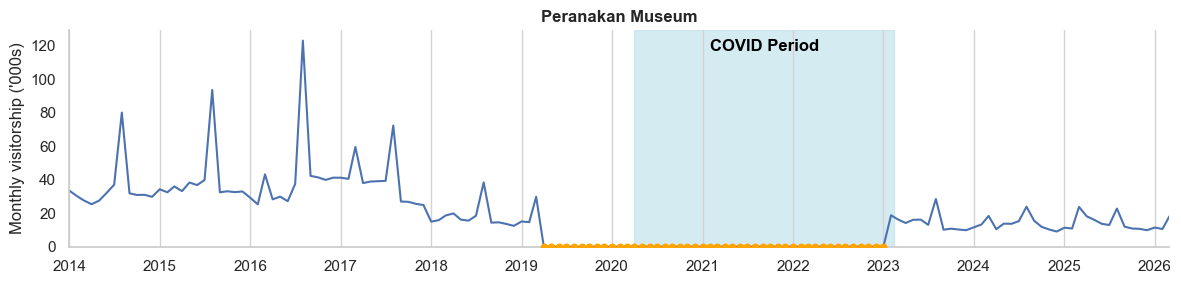

In [340]:
# Monthly visitorship per museum against the COVID period (shared x range).
for museum_name, group in visitors_df.groupby("Data Series"):
    plot_covid_period(
        group,
        title=museum_name,
        xmin=xmin,
        xmax=xmax,
        covid_start=COVID_START,
        covid_end=COVID_END,
    )

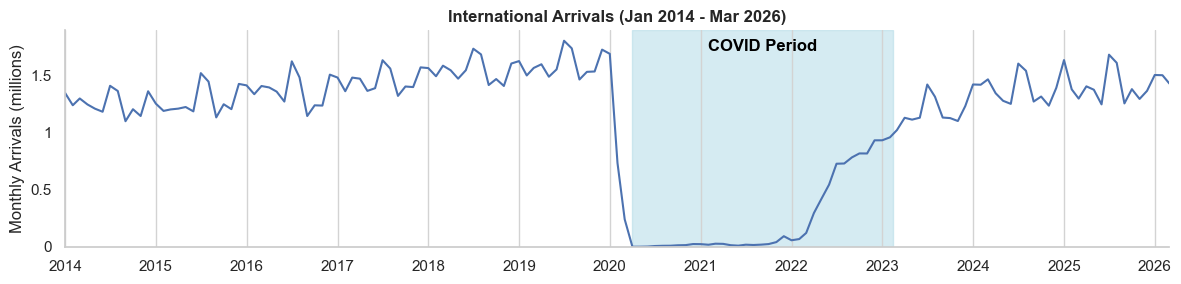

In [341]:
# Monthly international visitor arrivals against the COVID period.
plot_covid_period(
    intl_arrivals_df,
    title=f"International Arrivals ({START_MONTH} {START_YEAR} - {END_MONTH} {END_YEAR})",
    xmin=xmin,
    xmax=xmax,
    covid_start=COVID_START,
    covid_end=COVID_END,
    ylabel="Monthly Arrivals (millions)",
    y_millions=True,
)

## 3. Bivariate Analysis


### Correlation between museum visitorship and international arrivals
Months when a museum is closed (zero or missing visitorship) are excluded. Reported over the full period and again excluding COVID (Apr 2020 - Feb 2023), since the shared collapse and recovery inflates the full-period figure.

In [342]:
# Correlate each museum's monthly visitorship against total international arrivals.
arrivals = intl_arrivals_df[["timestamp", "value"]].rename(
    columns={"value": "intl_arrivals"}
)

rows = []
for code, group in visitors_df.groupby("code"):
    merged = group[["timestamp", "value"]].merge(arrivals, on="timestamp", how="inner")

    # Closures show up as zero visitorship
    open_months = merged[merged["value"] > 0]
    ex_covid = open_months[
        (open_months["timestamp"] < COVID_START) | (open_months["timestamp"] > COVID_END)
    ]

    rows.append(
        {
            "code": code,
            "n_full": len(open_months),
            "pearson_full": open_months["value"].corr(open_months["intl_arrivals"]),
            "spearman_full": open_months["value"].corr(
                open_months["intl_arrivals"], method="spearman"
            ),
            "n_ex_covid": len(ex_covid),
            "pearson_ex_covid": ex_covid["value"].corr(ex_covid["intl_arrivals"]),
            "spearman_ex_covid": ex_covid["value"].corr(
                ex_covid["intl_arrivals"], method="spearman"
            ),
        }
    )

print(f"{START_MONTH} {START_YEAR} to {END_MONTH} {END_YEAR}:")
correlations = pd.DataFrame(rows).set_index("code").round(3)
correlations

Jan 2014 to Mar 2026:


,n_full,pearson_full,spearman_full,n_ex_covid,pearson_ex_covid,spearman_ex_covid
code,,,,,,
ACM,146,0.782,0.771,112,0.554,0.570
IHC,129,0.615,0.619,96,0.165,0.234
MHC,104,0.826,0.893,75,0.675,0.781
NMS,146,0.614,0.532,112,0.422,0.357
TPM,101,0.072,0.005,100,0.063,0.004


## 4. Temporal Structure


### Tests for Stationarity

### Differencing

### ACF and PACF Plots
For determining `d` and `D` for SARIMAX

## 5. Anomalies and Special Cases


### Investigate each museum's seasonal peaks


In [343]:
# Make sure latest versions of the packages are imported
import src.events.month_range
import src.events.event_range
importlib.reload(src.events.month_range)
importlib.reload(src.events.event_range)

from src.events.month_range import MonthRange
from src.events.event_range import EventRange

# These are events where we are analysing theit imapct for all museums; 
# the museum-specific ones come later in this section.
GENERAL_EVENTS = [
    "chinese_new_year",
    "deepavali",
    "hari_raya_puasa",
    "national_day",
    "singapore_art_week",
    "singapore_night_festival",
]

month_ranges = MonthRange.from_csv()
event_ranges = EventRange.from_folder(names=GENERAL_EVENTS)

FOOTNOTE = (
    f"COVID period ({COVID_START:%b %Y} - {COVID_END:%b %Y}) and months with "
    "zero or missing visitorship excluded."
)

ACM

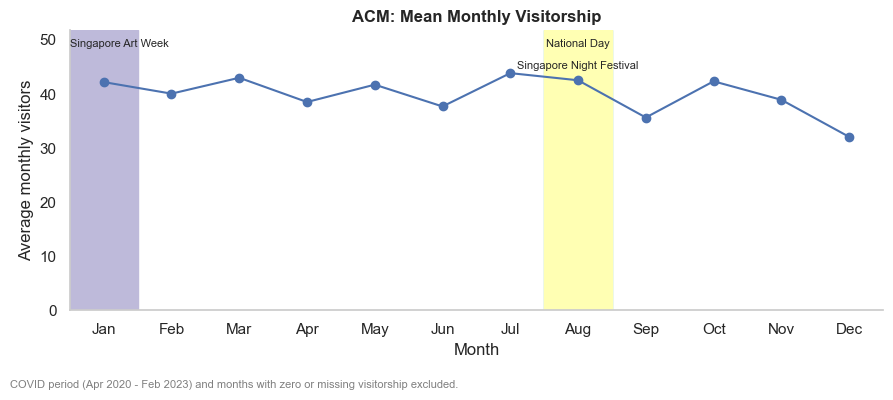

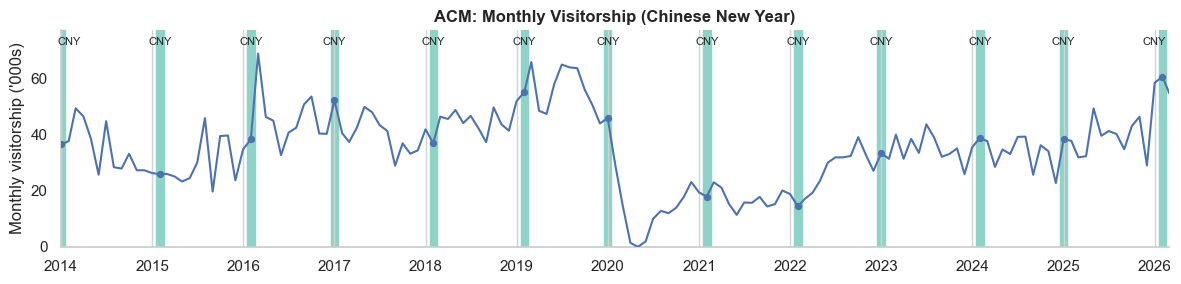

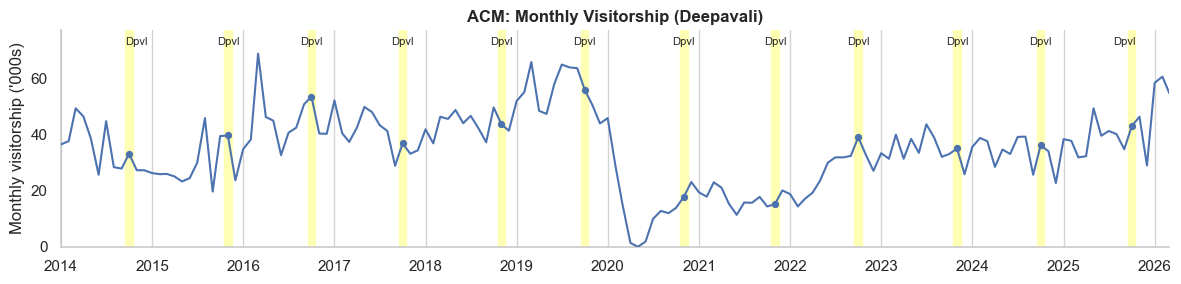

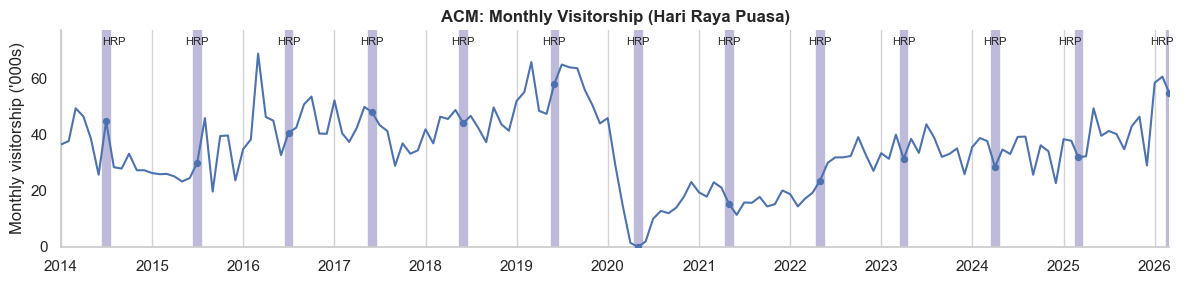

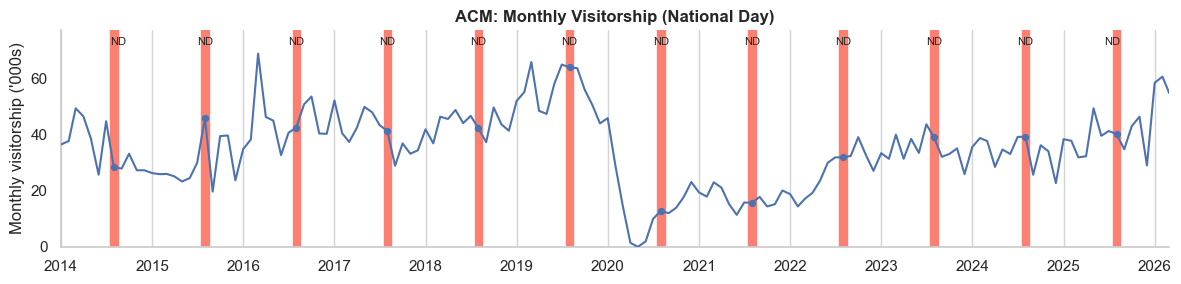

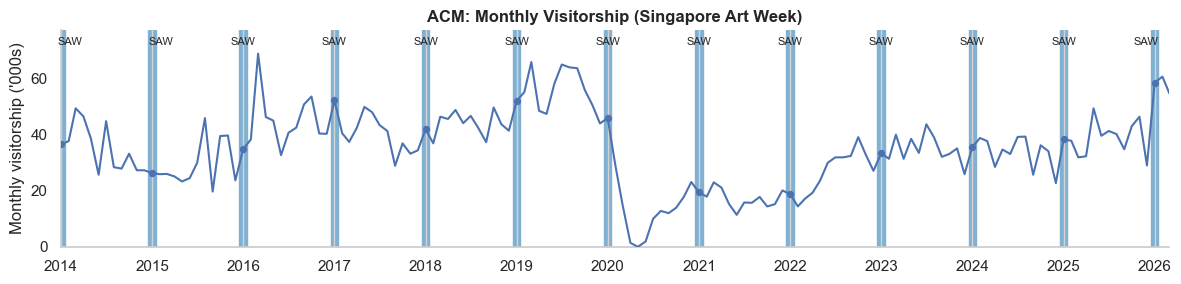

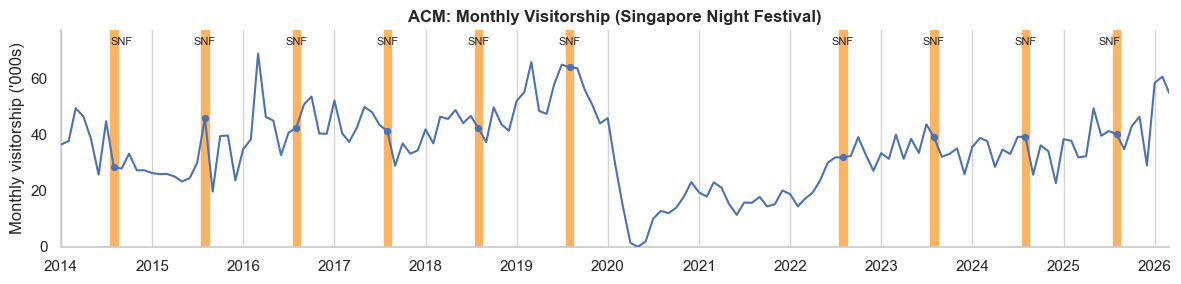

In [344]:
# Mean visitorship by calendar month, then the full series with every event occurrence
acm = visitors_df[visitors_df["code"] == "ACM"]
plot_seasonal_profile(
    acm,
    title="ACM: Mean Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    exclude_ranges=[(COVID_START, COVID_END)],
    month_ranges=month_ranges,
    footnote=FOOTNOTE,
)

# One plot per event, each in its own colour
plot_event_periods(
    acm,
    title="ACM: Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    event_ranges=event_ranges,
)

IHC

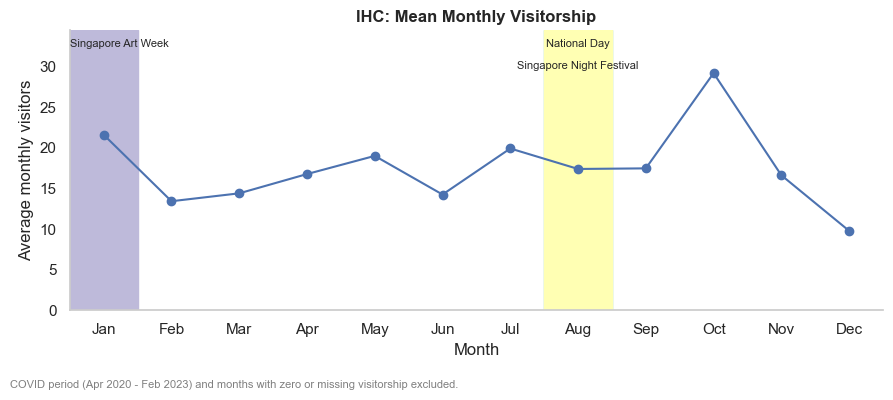

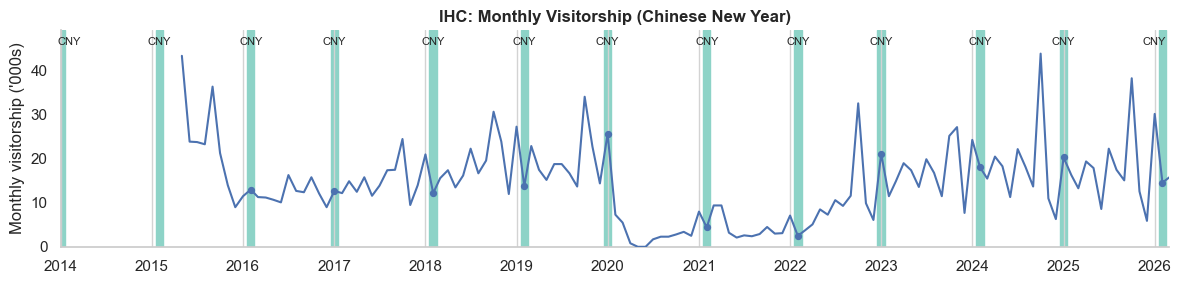

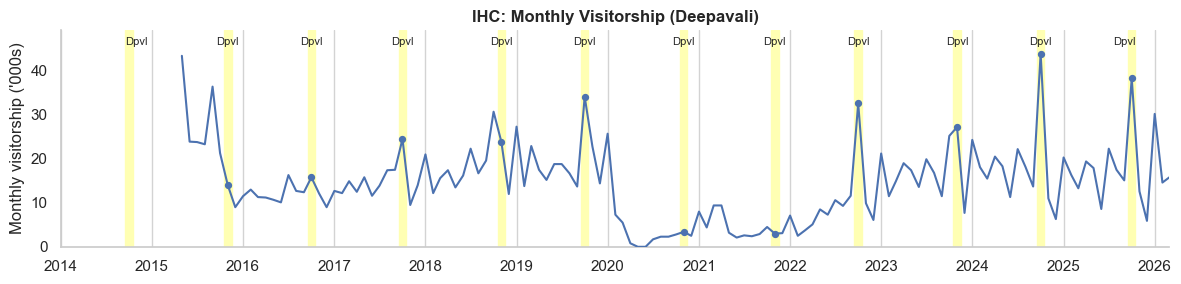

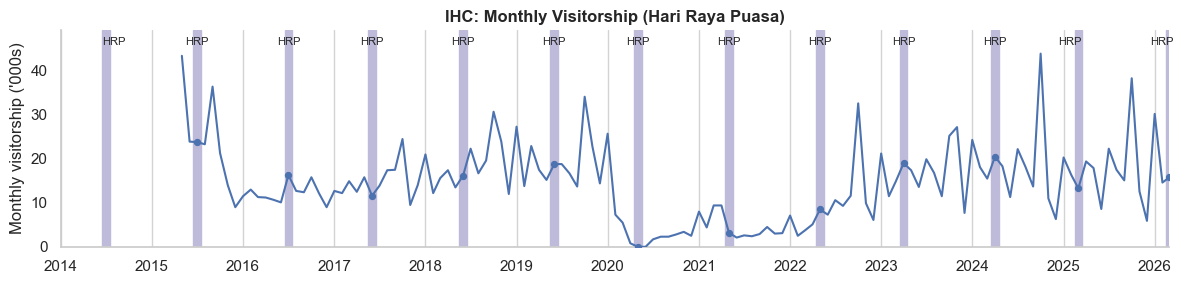

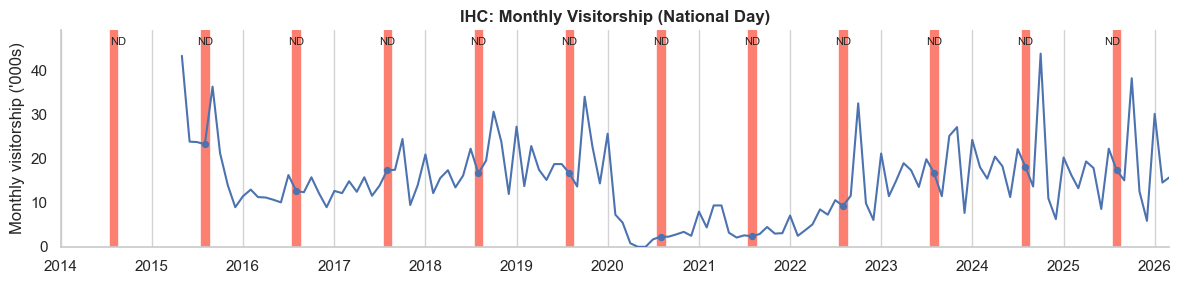

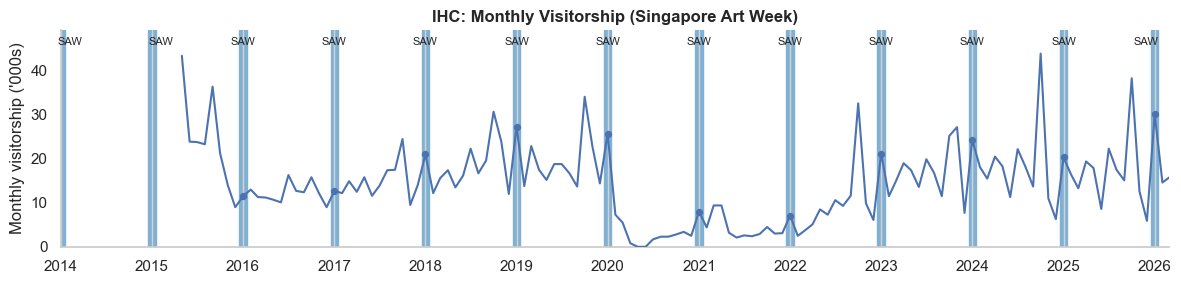

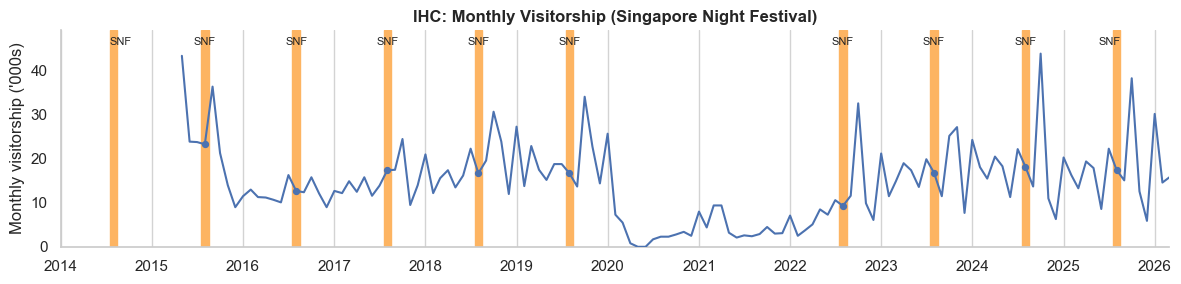

In [345]:
# Mean visitorship by calendar month, then the full series with every event occurrence
ihc = visitors_df[visitors_df["code"] == "IHC"]
plot_seasonal_profile(
    ihc,
    title="IHC: Mean Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    exclude_ranges=[(COVID_START, COVID_END)],
    month_ranges=month_ranges,
    footnote=FOOTNOTE,
)

# One plot per event, each in its own colour
plot_event_periods(
    ihc,
    title="IHC: Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    event_ranges=event_ranges,
)

MHC

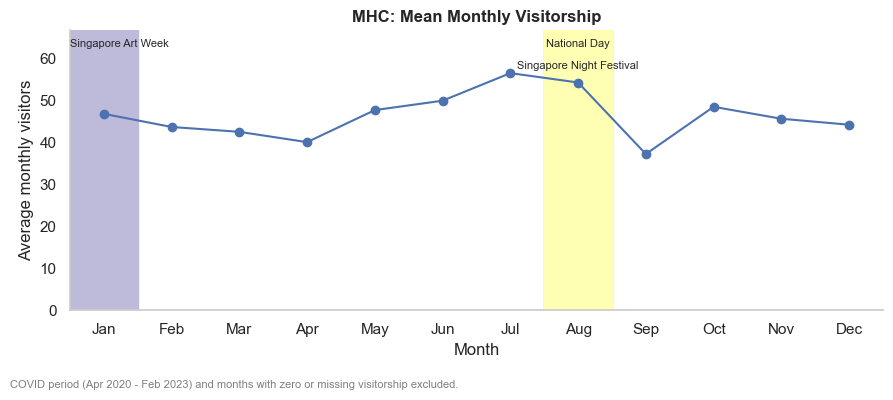

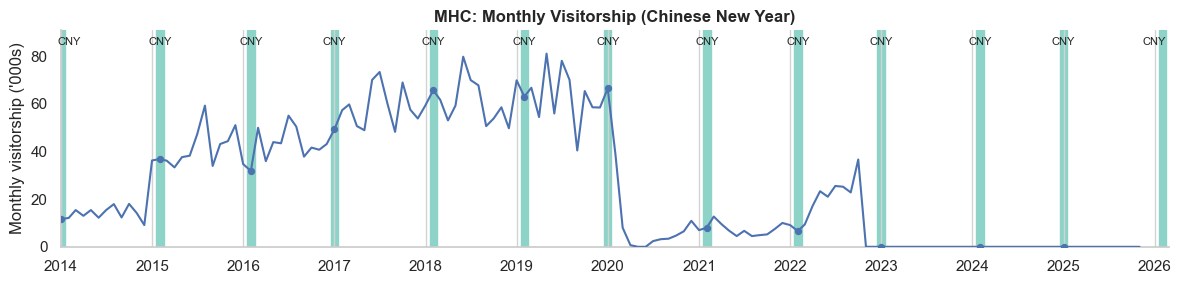

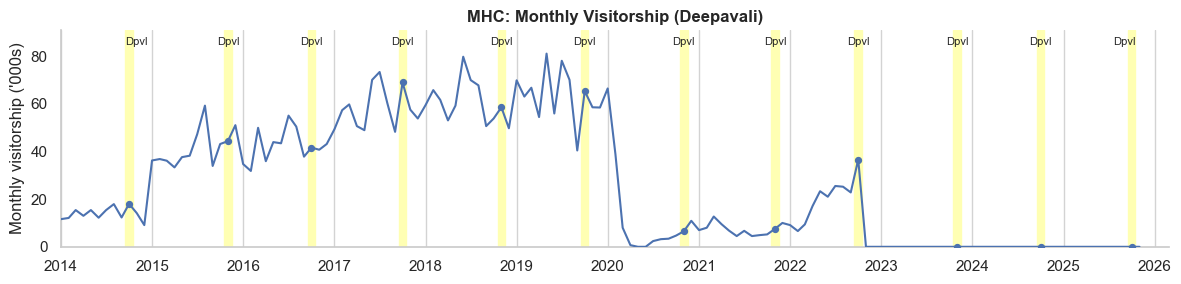

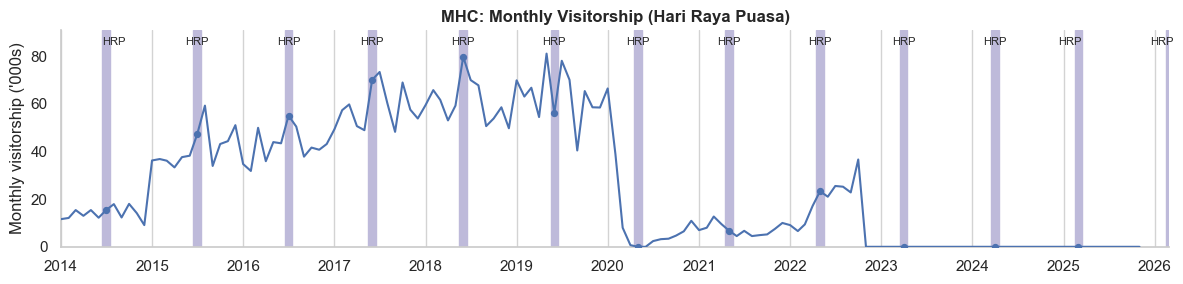

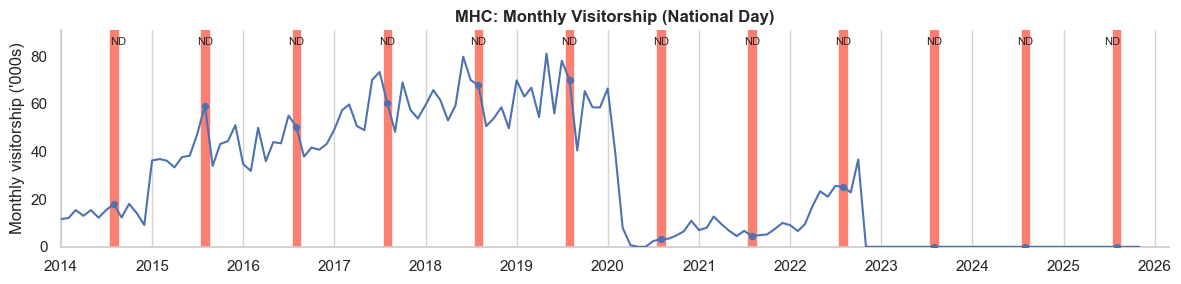

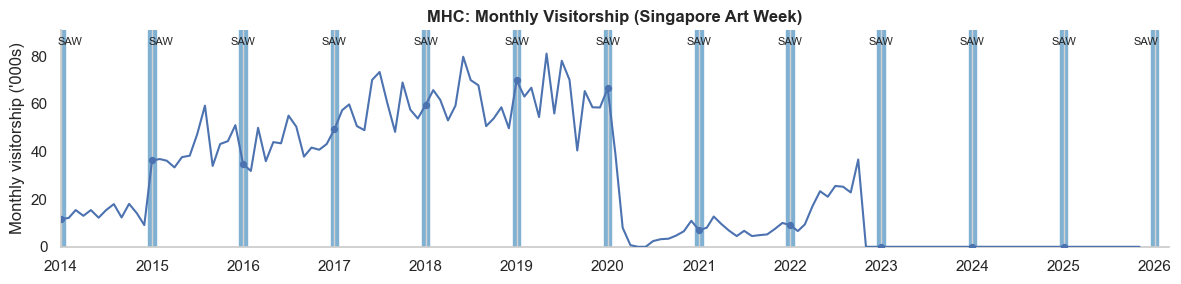

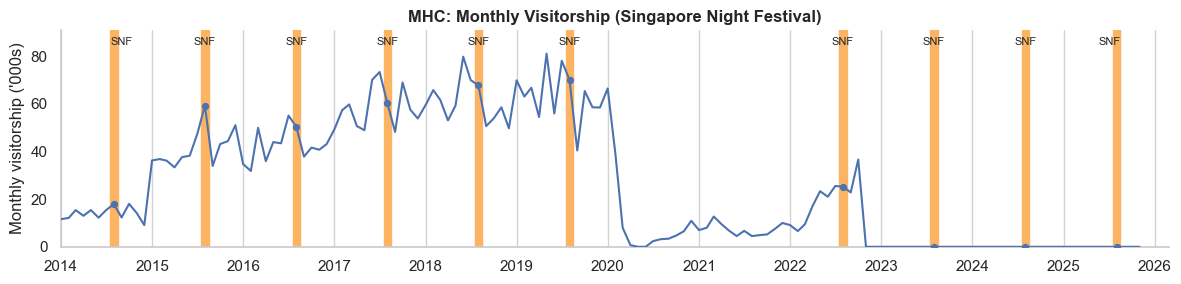

In [346]:
# Mean visitorship by calendar month, then the full series with every event occurrence
mhc = visitors_df[visitors_df["code"] == "MHC"]
plot_seasonal_profile(
    mhc,
    title="MHC: Mean Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    exclude_ranges=[(COVID_START, COVID_END)],
    month_ranges=month_ranges,
    footnote=FOOTNOTE,
)

# One plot per event, each in its own colour
plot_event_periods(
    mhc,
    title="MHC: Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    event_ranges=event_ranges,
)

NMS

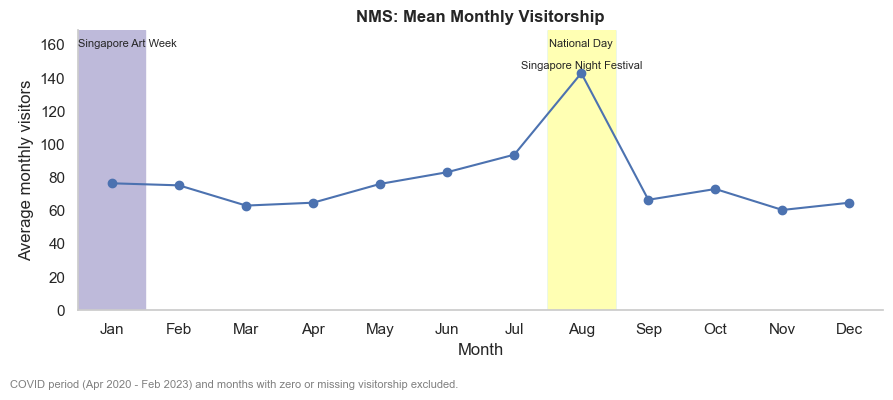

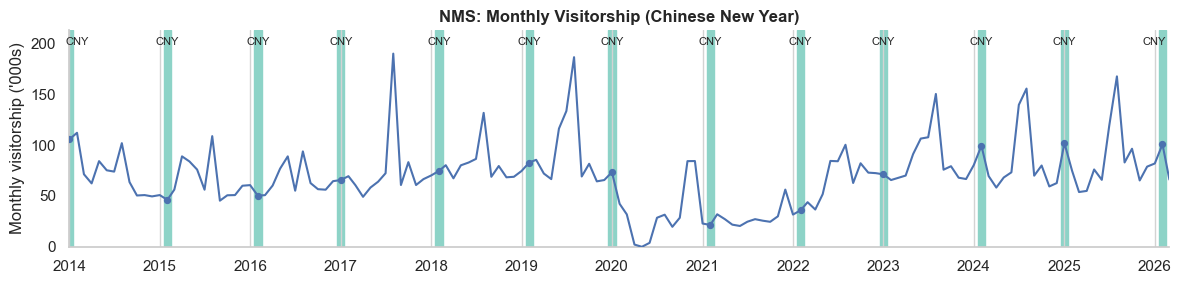

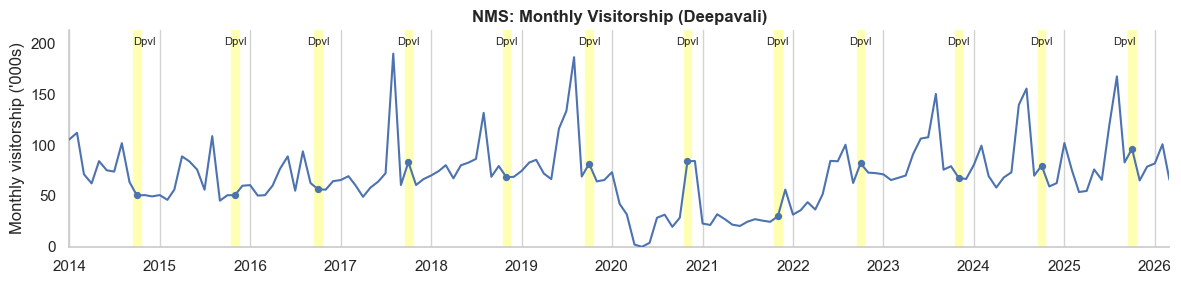

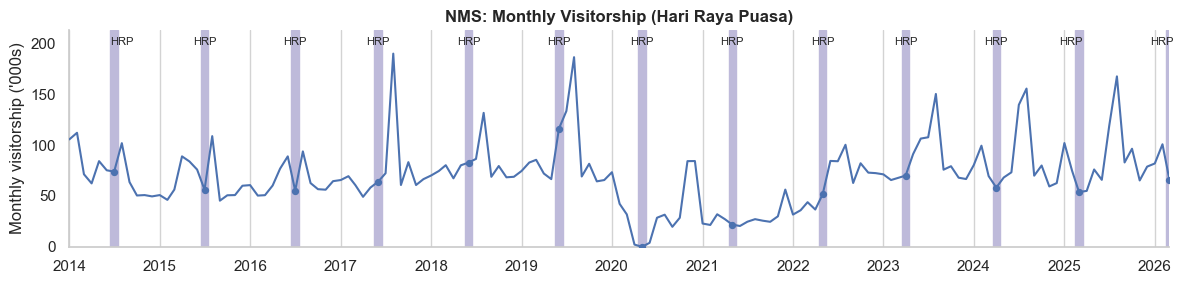

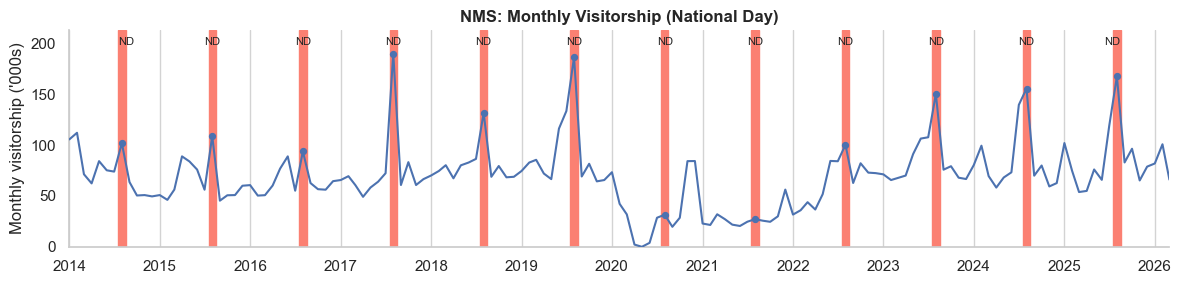

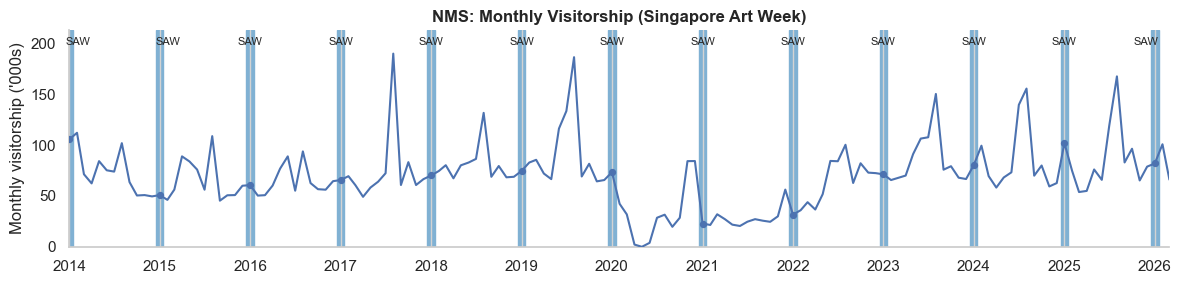

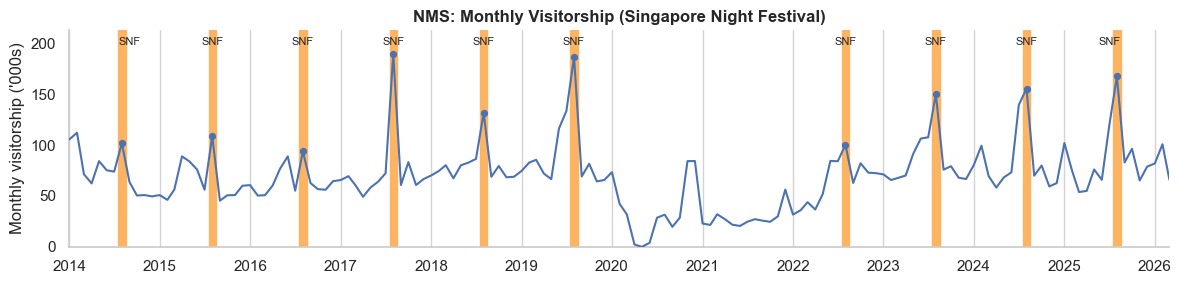

In [347]:
# Mean visitorship by calendar month, then the full series with every event occurrence
nms = visitors_df[visitors_df["code"] == "NMS"]
plot_seasonal_profile(
    nms,
    title="NMS: Mean Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    exclude_ranges=[(COVID_START, COVID_END)],
    month_ranges=month_ranges,
    footnote=FOOTNOTE,
)

# One plot per event, each in its own colour
plot_event_periods(
    nms,
    title="NMS: Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    event_ranges=event_ranges,
)

TPM

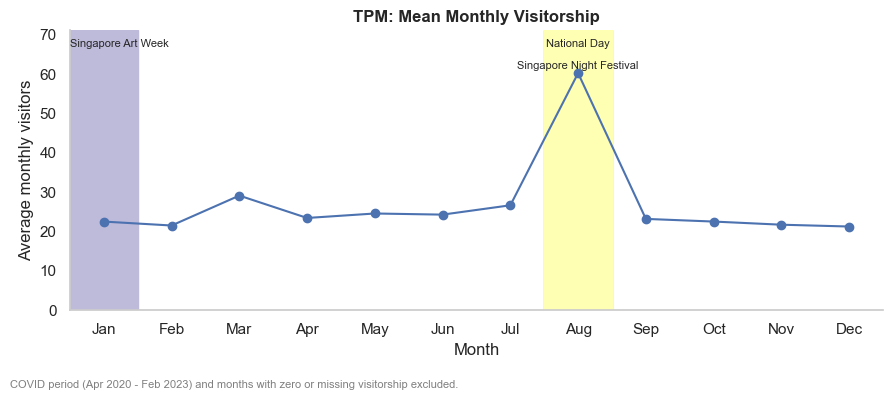

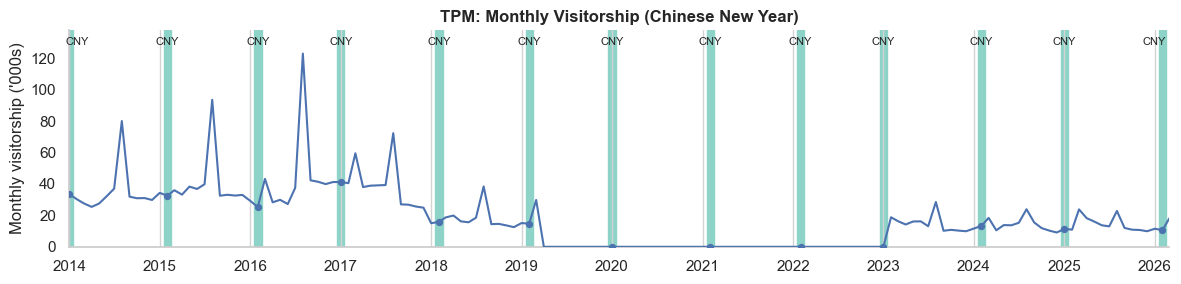

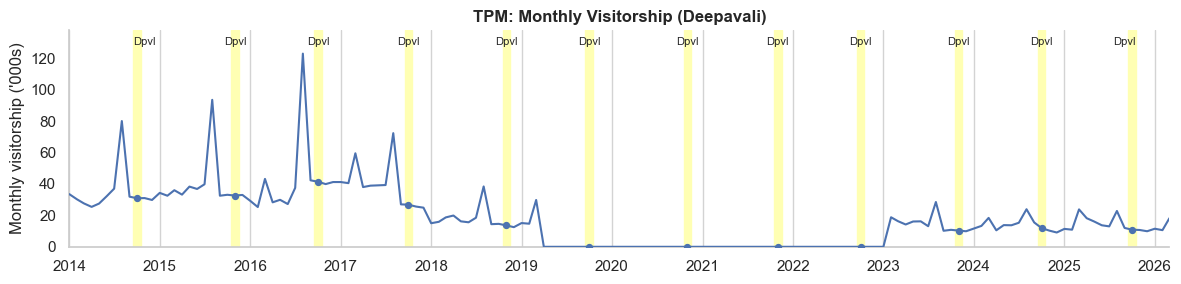

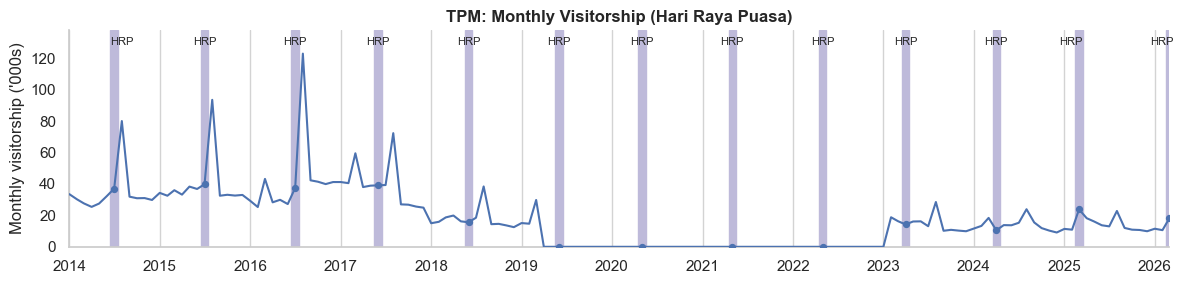

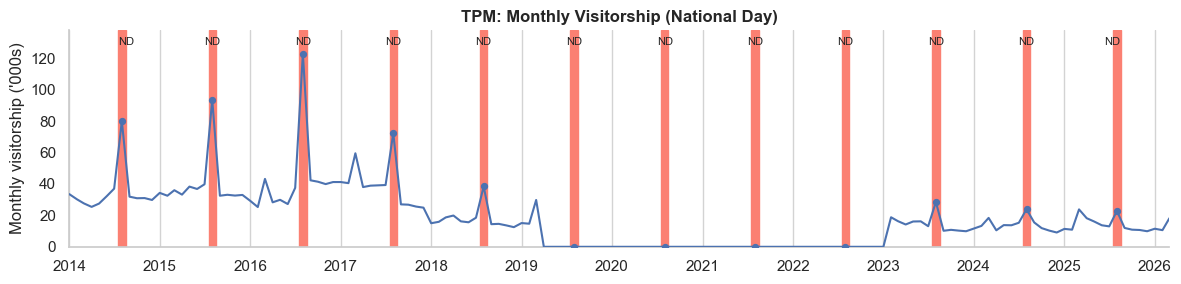

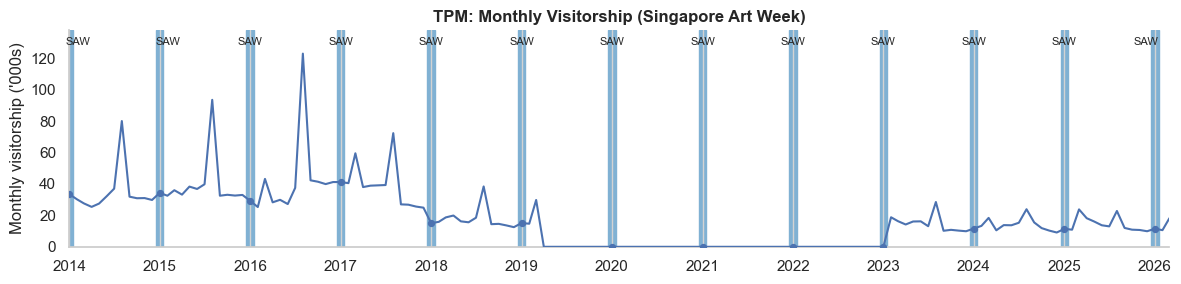

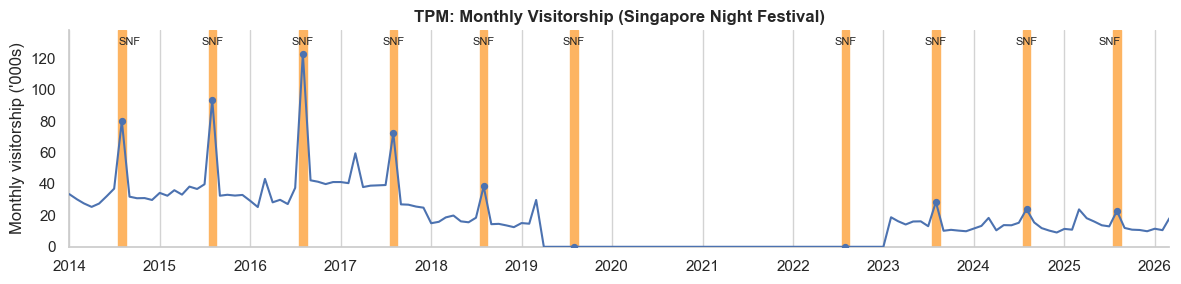

In [348]:
# Mean visitorship by calendar month, then the full series with every event occurrence
tpm = visitors_df[visitors_df["code"] == "TPM"]
plot_seasonal_profile(
    tpm,
    title="TPM: Mean Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    exclude_ranges=[(COVID_START, COVID_END)],
    month_ranges=month_ranges,
    footnote=FOOTNOTE,
)

# One plot per event, each in its own colour
plot_event_periods(
    tpm,
    title="TPM: Monthly Visitorship",
    xmin=xmin,
    xmax=xmax,
    event_ranges=event_ranges,
)

### Other museum specific drifting events

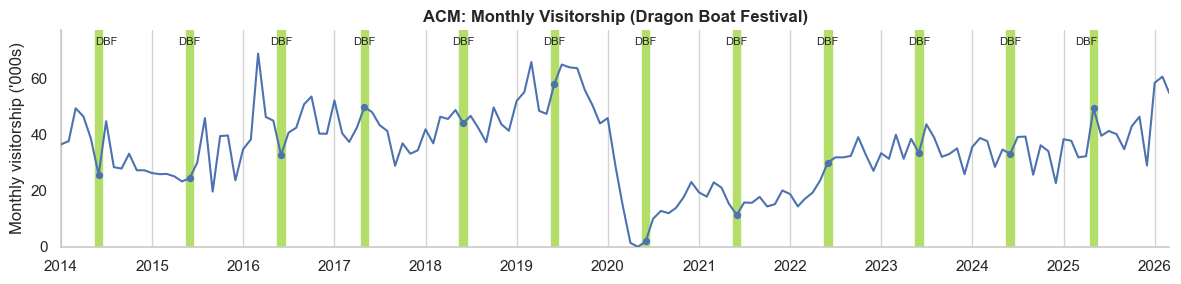

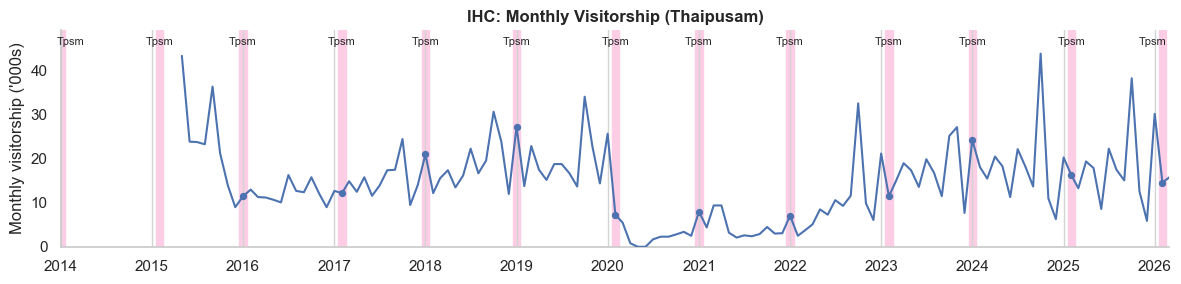

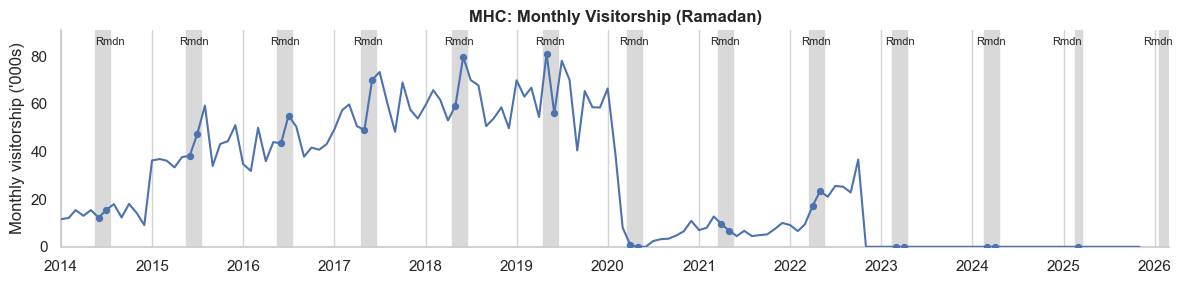

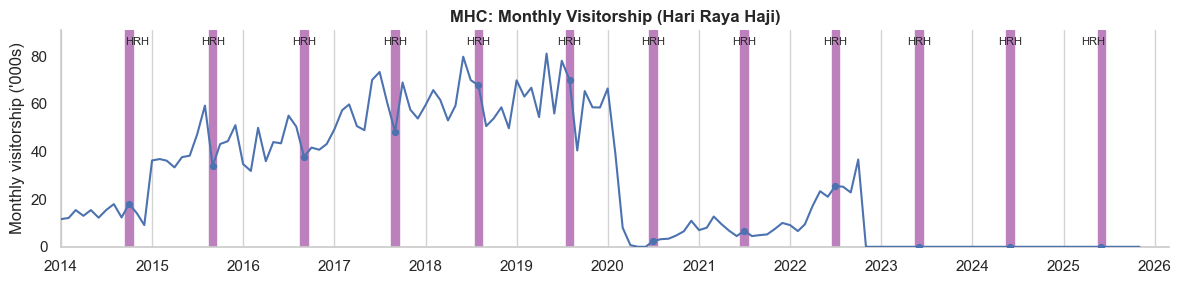

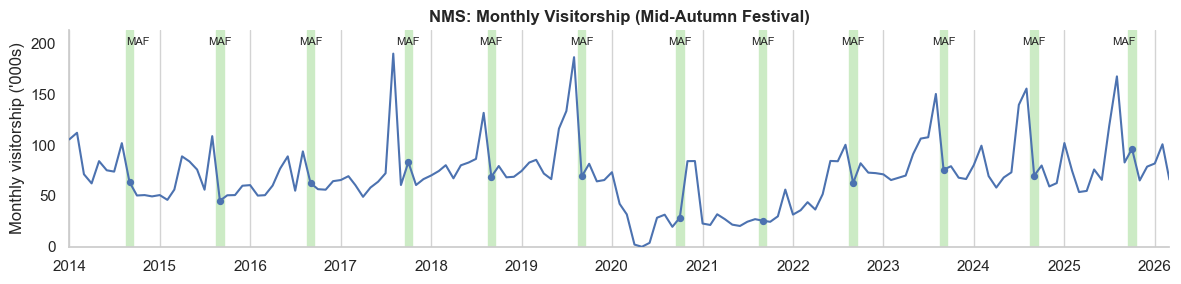

In [349]:
# Drifting events that should only move the museum they belong to
MUSEUM_EVENTS = {
    "ACM": ["dragon_boat_festival"],
    "IHC": ["thaipusam"],
    "MHC": ["ramadan", "hari_raya_haji"],
    "NMS": ["mid_autumn_festival"],
}

# Continue Set3 where the general events stopped, so no two events share a colour
museum_events = {code: EventRange.from_folder(names=names) for code, names in MUSEUM_EVENTS.items()}
palette = sns.color_palette("Set3", 12)[len(GENERAL_EVENTS):]

# One shared colour map, so each event keeps its own colour across the museums
colors = event_colors(
    [e for events in museum_events.values() for e in events], palette=palette
)

for code, events in museum_events.items():
    plot_event_periods(
        visitors_df[visitors_df["code"] == code],
        title=f"{code}: Monthly Visitorship",
        xmin=xmin,
        xmax=xmax,
        event_ranges=events,
        colors=colors,
    )

## 6. Analysis of Effects of Various Methods of Imputation of Future Feature Values for Forecasting Museum Visitorship

Background:
- This section aims to study the effects of certain decisions made by the team who wrote the old code
    - future unknown values for lag features were imputed by historical (2014-2026) monthly means
    - they did not replicate the imputation for test set, instead simply using known lag feature values (which does not reflect real predictions)
- Additionally, we will study which method is best for imputing future values for a new feature: `intl_arrivals`

<hr>

In [350]:
import src.features.data_prep

importlib.reload(src.features.data_prep)
from config import h
from src.features.data_prep import (
    PERIOD_END,
    ImputeRange,
    engineer_features,
    impute_monthly_avg,
    pad_to_period_end,
)

# The pipeline averages over engineered history, which starts 12 months late because
# engineer_features drops the rows the lag features cannot fill. Pad first, exactly as
# prepare_predict_data does, so a museum whose data stops early still ends at PERIOD_END
histories = {
    code: engineer_features(
        pad_to_period_end(visitors[visitors["Data Series"] == name]), intl_arrivals
    )
    for name, code in MUSEUM_CODES.items()
}

# Test ranges from the 80/20 split in prepare_eval_data, 
# NOTE: for now, these are hardcoded so they go stale if the config date range changes
TEST_RANGES = {
    "ACM": (pd.Timestamp("2024-01-01"), pd.Timestamp("2026-03-01")),
    "NMS": (pd.Timestamp("2024-01-01"), pd.Timestamp("2026-03-01")),
    "TPM": (pd.Timestamp("2024-01-01"), pd.Timestamp("2026-03-01")),
    "IHC": (pd.Timestamp("2024-04-01"), pd.Timestamp("2026-03-01")),
    "MHC": (pd.Timestamp("2023-09-01"), pd.Timestamp("2025-11-01")),
}

# Every museum predicts the same h months on from PERIOD_END, as prepare_predict_data does
PREDICT_RANGE = ImputeRange(
    "Predict period",
    PERIOD_END + pd.DateOffset(months=1),
    PERIOD_END + pd.DateOffset(months=h),
)

IMPUTE_RANGES = {
    code: [ImputeRange("Test period", *TEST_RANGES[code]), PREDICT_RANGE]
    for code in MUSEUM_CODES.values()
}

# Shared right-hand bound so every plot in this section spans the same axis
pred_xmax = PREDICT_RANGE.end


def plot_imputations(df, name, impute_ranges, window_years=None, ylabel="Monthly visitorship ('000s)", y_millions=False):
    """Plot a series' actuals with every given range imputed, on a single plot.

    Args:
        df (pd.DataFrame): Actuals, with 'timestamp' and 'value' columns.
        name (str): Series name for the title, e.g. "ACM" or "International Arrivals".
        impute_ranges (list[ImputeRange]): Labelled ranges to impute.
        window_years (int | None): Years of history to average over; None uses all
            history before each range, as the pipeline does today.
        ylabel (str): Y-axis label (default is museum visitorship in thousands).
        y_millions (bool): If True, label y ticks in millions instead of a 1e6 offset.
    """
    method = "full period" if window_years is None else f"past {window_years}-year"

    imputed = impute_monthly_avg(df, impute_ranges, window_years=window_years)
    plot_imputed_period(
        df,
        imputed,
        impute_ranges,
        title=f"{name}: Imputed with {method} historical monthly mean",
        xmin=df["timestamp"].min(),
        xmax=pred_xmax,
        ylabel=ylabel,
        y_millions=y_millions,
    )

Visitorship by Museum (Jan 2014 - Mar 2026 - Mar 2028)

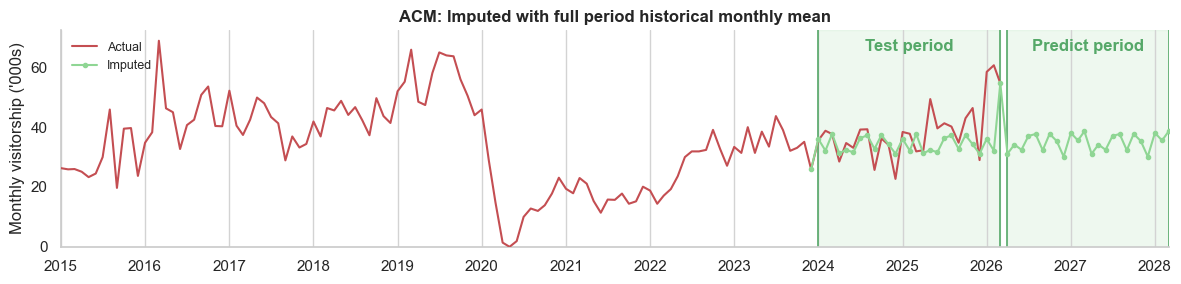

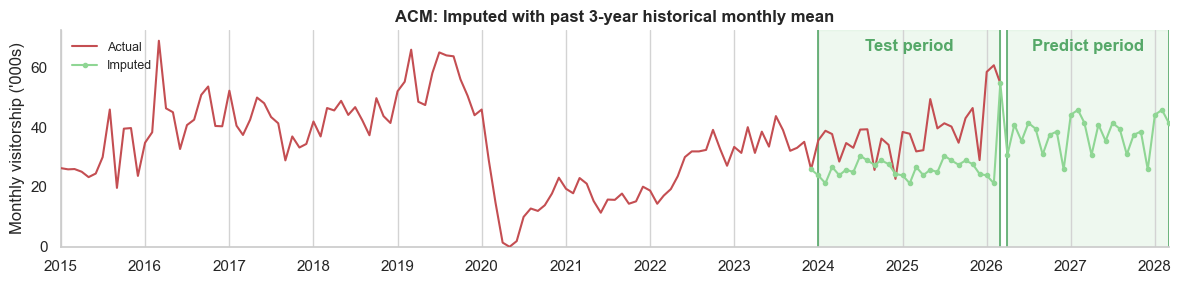

In [351]:
# ACM: test and predict periods imputed with the full period historical monthly mean
plot_imputations(histories["ACM"], "ACM", IMPUTE_RANGES["ACM"])

# The same two periods, imputed with the past 3-year historical monthly mean
plot_imputations(histories["ACM"], "ACM", IMPUTE_RANGES["ACM"], window_years=3)

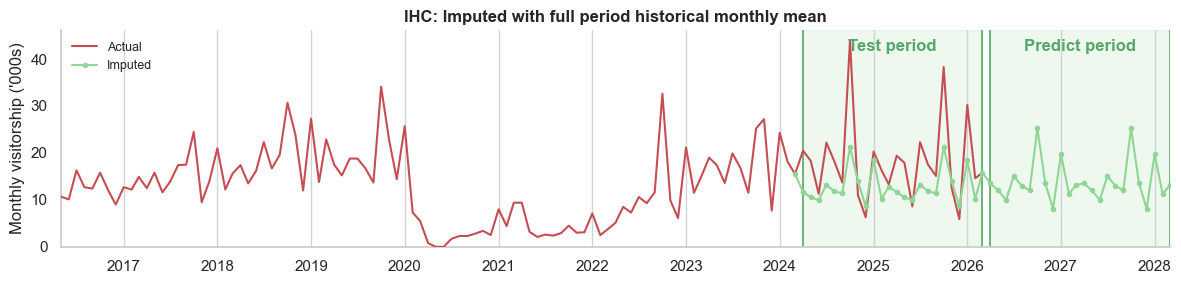

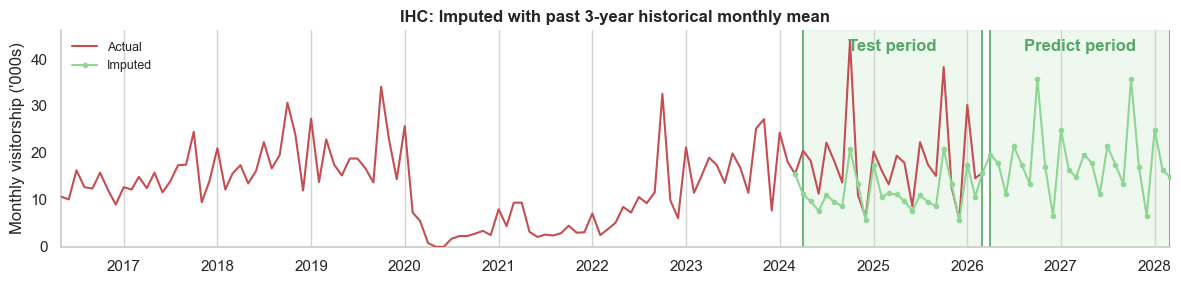

In [352]:
# IHC: test and predict periods imputed with the full period historical monthly mean
plot_imputations(histories["IHC"], "IHC", IMPUTE_RANGES["IHC"])

# The same two periods, imputed with the past 3-year historical monthly mean
plot_imputations(histories["IHC"], "IHC", IMPUTE_RANGES["IHC"], window_years=3)

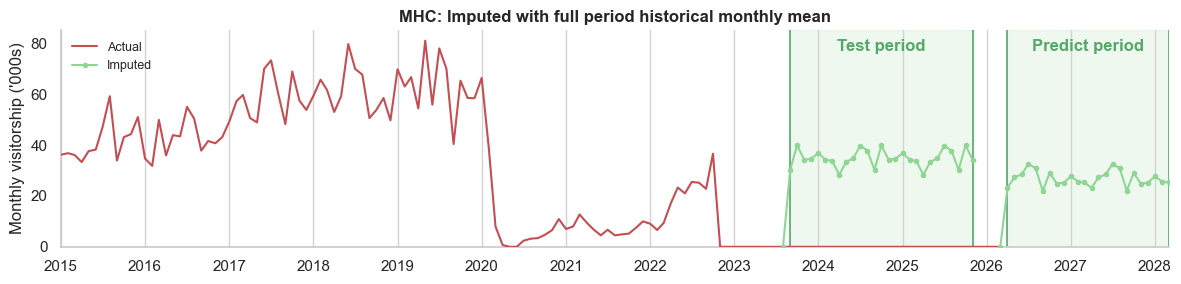

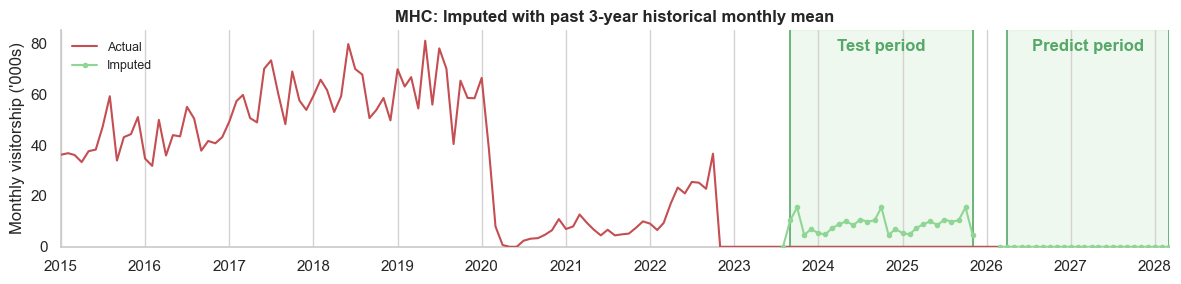

In [353]:
# MHC: test and predict periods imputed with the full period historical monthly mean
plot_imputations(histories["MHC"], "MHC", IMPUTE_RANGES["MHC"])

# The same two periods, imputed with the past 3-year historical monthly mean
plot_imputations(histories["MHC"], "MHC", IMPUTE_RANGES["MHC"], window_years=3)

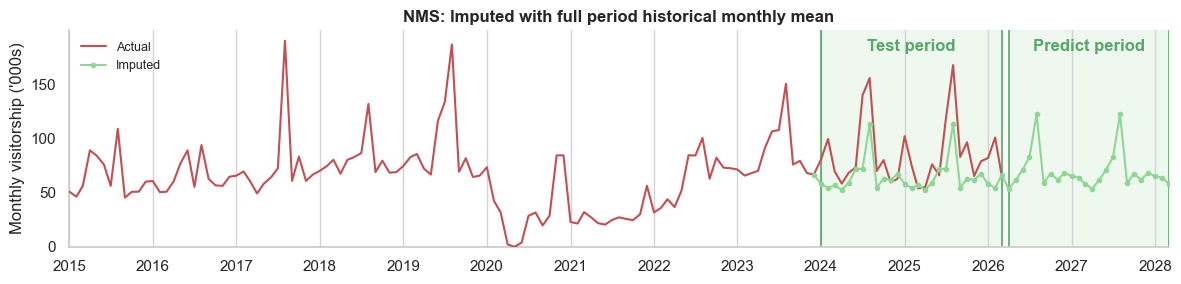

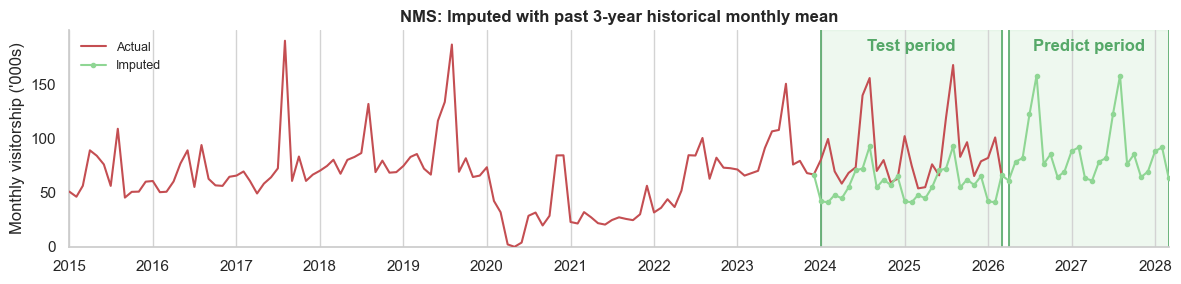

In [354]:
# NMS: test and predict periods imputed with the full period historical monthly mean
plot_imputations(histories["NMS"], "NMS", IMPUTE_RANGES["NMS"])

# The same two periods, imputed with the past 3-year historical monthly mean
plot_imputations(histories["NMS"], "NMS", IMPUTE_RANGES["NMS"], window_years=3)

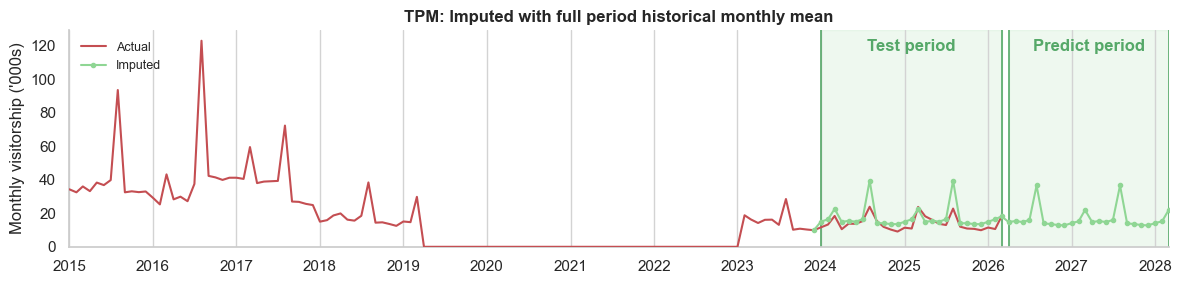

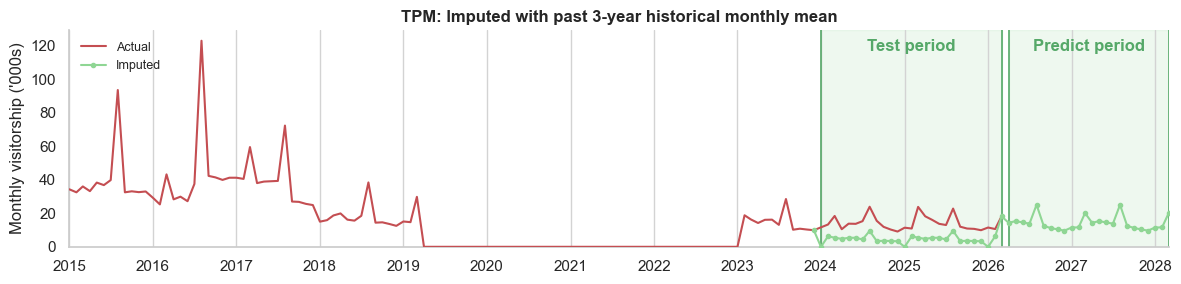

In [355]:
# TPM: test and predict periods imputed with the full period historical monthly mean
plot_imputations(histories["TPM"], "TPM", IMPUTE_RANGES["TPM"])

# The same two periods, imputed with the past 3-year historical monthly mean
plot_imputations(histories["TPM"], "TPM", IMPUTE_RANGES["TPM"], window_years=3)

International Arrivals (Jan 2014 - Mar 2026)

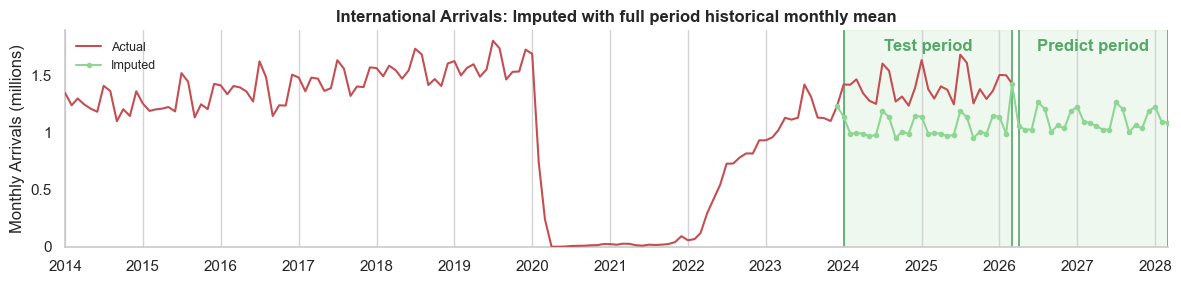

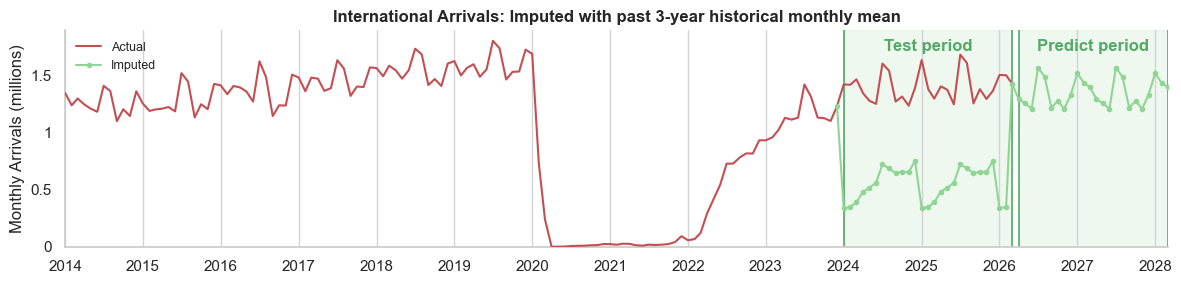

In [356]:
# Arrivals are one series, so the test period uses the range four of the five museums
# share; the predict period is the same for every museum
ARRIVALS_RANGES = [
    ImputeRange("Test period", *TEST_RANGES["ACM"]),
    PREDICT_RANGE,
]

# Future intl_arrivals imputed with the full period historical monthly mean, as the
# pipeline does today. The test period is imputed too: the pipeline feeds the models
# real arrivals when evaluating, which they would never have at prediction time
plot_imputations(
    intl_arrivals_df,
    "International Arrivals",
    ARRIVALS_RANGES,
    ylabel="Monthly Arrivals (millions)",
    y_millions=True,
)

# The same two periods, imputed with the past 3-year historical monthly mean
plot_imputations(
    intl_arrivals_df,
    "International Arrivals",
    ARRIVALS_RANGES,
    window_years=3,
    ylabel="Monthly Arrivals (millions)",
    y_millions=True,
)

Conclusion:
- Imputation of predict range's monthly lag features and `intl_arrivals` with their respective full period historical monthly means will underrepresent them for the predict period, and therefore underpredict
- Imputation with only the past 3-year historical monthly means, will yield better representations for the predict period, but will massively underrepresent the test period as the observation window to build the 3-year historical means cuts into the later half of COVID and the first few recovery years.

I think the best way to impute monthly lag features is to reuse the model's own predictions, as the alternative as shown above is flawed estimating predict period and test period imputations

For intl_arrivals, I think we have to train another model to forecast the intl_arrivals for the test and predict periods,, and feed those outputs into the museum visitorship models